In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Input, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Nadam
from tensorflow.keras.callbacks import EarlyStopping
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
filename = 'jena_climate_10k.csv'
df = pd.read_csv(filename)


# --- KONFIGURACJA KOLUMN ---
TARGET_COL = 'T (degC)'

# Lista kolumn do usunięcia wskazana przez Ciebie
COLS_TO_DROP = [
    'Date Time',
    'Tpot (K)',
    'VPact (mbar)',
    'H2OC (mmol/mol)',
    'wv (m/s)',
    'VPmax (mbar)',
    'Tdew (degC)'
]

# Dodajemy 'Set' do usuwanych, jeśli istnieje w pliku (na wszelki wypadek)
if 'Set' in df.columns:
    COLS_TO_DROP.append('Set')

# Ostateczna lista cech (wszystko co nie jest celem i nie jest do usunięcia)
FEATURE_COLS = [c for c in df.columns if c not in COLS_TO_DROP and c != TARGET_COL]

print(f"Liczba cech wejściowych: {len(FEATURE_COLS)}")
print(f"Cechy: {FEATURE_COLS}")

# --- PODZIAŁ DANYCH (70% / 15% / 15%) ---
n = len(df)
train_split = int(n * 0.70)
val_split   = int(n * 0.85)  # 70% + 15% = 85%

train_df = df[0 : train_split]
val_df   = df[train_split : val_split]
test_df  = df[val_split :]

print(f"Podział danych: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# --- SKALOWANIE ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit (uczymy skaler) tylko na zbiorze treningowym
X_train_raw = scaler_X.fit_transform(train_df[FEATURE_COLS].values)
y_train_raw = scaler_y.fit_transform(train_df[[TARGET_COL]].values)

# Transformujemy resztę używając parametrów z train
X_val_raw = scaler_X.transform(val_df[FEATURE_COLS].values)
y_val_raw = scaler_y.transform(val_df[[TARGET_COL]].values)

X_test_raw = scaler_X.transform(test_df[FEATURE_COLS].values)
y_test_raw_orig = test_df[[TARGET_COL]].values

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# --- Przygotowanie danych RAZ przed pętlą (przeniesione tutaj) ---
ts = 24  # Ustawienie stałej wartości time_steps


X_train, y_train_scaled = create_sequences(X_train_raw, y_train_raw, ts)
X_val, y_val_scaled = create_sequences(X_val_raw, y_val_raw, ts)
X_test, y_true_test = create_sequences(X_test_raw, y_test_raw_orig, ts)

# Prawdziwe wartości (do liczenia metryk) - liczymy raz
y_true_train = scaler_y.inverse_transform(y_train_scaled)
y_true_val = scaler_y.inverse_transform(y_val_scaled)


Liczba cech wejściowych: 7
Cechy: ['p (mbar)', 'rh (%)', 'VPdef (mbar)', 'sh (g/kg)', 'rho (g/m**3)', 'max. wv (m/s)', 'wd (deg)']
Podział danych: Train=7000, Val=1500, Test=1500


In [5]:


# ==========================================
# 2. BUDOWNICZY MODELU (CNN)
# ==========================================
def build_cnn_model(input_shape, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Warstwy Konwolucyjne (Conv1D)
    for i in range(params['num_layers']):
        model.add(Conv1D(filters=params['filters'],
                         kernel_size=params['kernel_size'],       # ZMIANA: kernel_size teraz z params
                         activation='relu',   # W CNN standardem jest ReLU
                         padding='same'))     # 'same' utrzymuje długość sekwencji

        # Opcjonalnie: MaxPooling co warstwę lub co drugą (tu dla uproszczenia po każdej)
        # Pomaga redukować wymiarowość i wyciągać najważniejsze cechy
        if i < params['num_layers']:
             model.add(MaxPooling1D(pool_size=2, padding='same'))

    # CNN zwraca mapę cech 3D, musimy ją spłaszczyć do 2D dla warstwy Dense
    model.add(Flatten())

    # Warstwy Dense (Gęste)
    model.add(Dense(params['dense_neurons'], activation='relu'))
    model.add(Dropout(0.2)) # Dropout przeniesiony tutaj, standard w CNN
    model.add(Dense(1))

    # Optymalizator
    lr = params['learning_rate']

    if params['optimizer'] == 'adam': opt = Adam(learning_rate=lr)
    elif params['optimizer'] == 'nadam': opt = Nadam(learning_rate=lr)
    elif params['optimizer'] == 'rmsprop': opt = RMSprop(learning_rate=lr)
    else: opt = Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='mse')
    return model

# ==========================================
# 3. KONFIGURACJA EKSPERYMENTÓW (CNN)
# ==========================================

BASELINE_CONFIG = {
    'group': 'BASELINE',
    'num_layers': 1,
    'filters': 64,             # ZMIANA NAZWY: 'units' -> 'filters'
    'dense_neurons': 64,
    'optimizer': 'adam',
    'learning_rate': 0.001,
    'momentum': 0.0,
    'epochs': 100,
    'time_steps': 24,
    'kernel_size': 3 # ZMIANA: Dodano domyślny kernel_size
}

TEST_GROUPS = {
    'Layers':       {'param': 'num_layers',    'values': [1, 2, 3, 4]},

    'Capacity':     {'param': 'filters',       'values': [16, 32, 64, 128]},

    'Optimizer':    {'param': 'optimizer',     'values': ['adam', 'nadam', 'rmsprop']},

    'LearningRate': {'param': 'learning_rate', 'values': [0.1, 0.01, 0.001, 0.0001]},

    'Epochs':       {'param': 'epochs',        'values': [25, 50, 100, 200]},

    'KernelSize':   {'param': 'kernel_size',   'values': [2, 3, 5, 7]} # ZMIANA: Dodano grupę testową dla kernel_size
}

experiments_queue = []
experiments_queue.append(BASELINE_CONFIG.copy())

for group_name, details in TEST_GROUPS.items():
    param_name = details['param']
    values = details['values']
    for val in values:
        new_cfg = BASELINE_CONFIG.copy()
        new_cfg['group'] = group_name

        # Dostosowanie logiki dla grupy Capacity (teraz operujemy na filters)
        if group_name == 'Capacity':
            new_cfg['filters'] = val       # ZMIANA: units -> filters
            new_cfg['dense_neurons'] = val
        else:
            new_cfg[param_name] = val

        # Zabezpieczenie przed duplikatami baseline
        if new_cfg[param_name] != BASELINE_CONFIG.get(param_name) or group_name == 'Capacity':
             experiments_queue.append(new_cfg)

# Usuwanie duplikatów (bez zmian)
unique_experiments = []
seen_configs = set()
for exp in experiments_queue:
    config_tuple = tuple(sorted((k, v) for k, v in exp.items() if k != 'group'))
    if config_tuple not in seen_configs:
        seen_configs.add(config_tuple)
        unique_experiments.append(exp)

experiments_queue = unique_experiments

print(f"Zaplanowano {len(experiments_queue)} zoptymalizowanych konfiguracji CNN.")

Zaplanowano 18 zoptymalizowanych konfiguracji CNN.


In [ ]:

# ==========================================
# 4. SILNIK WYKONAWCZY (TRAIN / VAL / TEST) - CNN
# ==========================================
N_REPEATS = 5  # Liczba powtórzeń dla każdego testu
results = []
current_run = 0
total_runs = len(experiments_queue) * N_REPEATS



print("Rozpoczynam pętlę eksperymentalną...")

for cfg in experiments_queue:
    # --- LOGIKA LOGOWANIA (Wykrywanie co testujemy) ---
    tested_param = "BASELINE"
    tested_val = "N/A"

    if cfg['group'] != 'BASELINE':
        # Szukamy różnic względem baseline
        diff = {k: cfg[k] for k in cfg if k in BASELINE_CONFIG and cfg[k] != BASELINE_CONFIG[k]}
        if diff:
            tested_param = list(diff.keys())[0]
            tested_val = diff[tested_param]

        # Specjalny przypadek dla Capacity (bo zmienia filters i dense_neurons)
        if cfg['group'] == 'Capacity':
            tested_param = 'filters'
            tested_val = cfg['filters']

    print(f"\n>>> BADANIE: {cfg['group']} | {tested_param} = {tested_val}")

    # Inicjalizacja słownika na wyniki
    metrics = {k: [] for k in ['Train_R2', 'Val_R2', 'Test_R2',
                               'Train_MAE', 'Val_MAE', 'Test_MAE',
                               'Train_MSE', 'Val_MSE', 'Test_MSE']}

    for i in range(N_REPEATS):
        current_run += 1

        # Budowa modelu (CNN)
        # WAŻNE: Tu wywołujemy build_cnn_model zamiast build_lstm_model
        model = build_cnn_model((X_train.shape[1], X_train.shape[2]), cfg)

        # Callbacki (Brak EarlyStopping tylko dla grupy Epochs, żeby sprawdzić pełny przebieg)
        cbs = [] if cfg['group'] == 'Epochs' else [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

        # Trening (Batch size 64 - zoptymalizowane pod CNN)
        model.fit(X_train, y_train_scaled, validation_data=(X_val, y_val_scaled),
                  epochs=cfg['epochs'], batch_size=128, verbose=0, callbacks=cbs)

        # Predykcja i odwrócenie skalowania
        p_train = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
        p_val   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
        p_test  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

        # Zabezpieczenie przed NaN (gdyby sieć "wybuchła")
        if np.isnan(p_test).any():
            print("! UWAGA: NaN w wynikach. Przypisuję błędy domyślne.")
            scores = [0]*3 + [999]*6
        else:
            # Obliczenie wszystkich metryk w jednym bloku
            scores = [
                r2_score(y_true_train, p_train), r2_score(y_true_val, p_val), r2_score(y_true_test, p_test),
                mean_absolute_error(y_true_train, p_train), mean_absolute_error(y_true_val, p_val), mean_absolute_error(y_true_test, p_test),
                mean_squared_error(y_true_train, p_train), mean_squared_error(y_true_val, p_val), mean_squared_error(y_true_test, p_test)
            ]

        # Zapis wyników do list
        for key, val in zip(metrics.keys(), scores):
            metrics[key].append(val)

        print(f"    Run {current_run}/{total_runs}: Test R2={metrics['Test_R2'][-1]:.4f} | MSE={metrics['Test_MSE'][-1]:.2f}")

    # Obliczanie średnich i zapis do listy głównej
    res = cfg.copy()
    for key, val_list in metrics.items():
        res[f'{key}_Mean'] = np.mean(val_list)

    res['Tested_Value'] = tested_val
    results.append(res)


Przygotowywanie sekwencji danych (time_steps=24)...
Rozpoczynam pętlę eksperymentalną...

>>> BADANIE: BASELINE | BASELINE = N/A
    Run 1/90: Test R2=0.9469 | MSE=0.33
    Run 2/90: Test R2=0.9293 | MSE=0.44
    Run 3/90: Test R2=0.9213 | MSE=0.49
    Run 4/90: Test R2=0.9660 | MSE=0.21
    Run 5/90: Test R2=0.9666 | MSE=0.21

>>> BADANIE: Layers | group = Layers
    Run 6/90: Test R2=0.9739 | MSE=0.16
    Run 7/90: Test R2=0.8987 | MSE=0.63
    Run 8/90: Test R2=0.9865 | MSE=0.08
    Run 9/90: Test R2=0.9821 | MSE=0.11
    Run 10/90: Test R2=0.9879 | MSE=0.08

>>> BADANIE: Layers | group = Layers
    Run 11/90: Test R2=0.9845 | MSE=0.10
    Run 12/90: Test R2=0.9898 | MSE=0.06
    Run 13/90: Test R2=0.9666 | MSE=0.21
    Run 14/90: Test R2=0.9734 | MSE=0.17
    Run 15/90: Test R2=0.9487 | MSE=0.32

>>> BADANIE: Layers | group = Layers
    Run 16/90: Test R2=0.9751 | MSE=0.15
    Run 17/90: Test R2=0.9510 | MSE=0.30
    Run 18/90: Test R2=0.9854 | MSE=0.09
    Run 19/90: Test R2=0.979

In [ ]:
# ==========================================
# 5. ZAPIS WYNIKÓW
# ==========================================
df_res = pd.DataFrame(results)
filename_out = 'wyniki_cnn_jena.csv'
df_res.to_csv(filename_out, index=False)

print("\n" + "="*40)
print("             KONIEC TESTÓW (CNN)        ")
print("="*40)
print(f"Pełne wyniki zapisano w: {filename_out}")

# Krótki podgląd Bazy
print("\n--- WYNIKI BAZOWE (BASELINE MEAN) ---")
base_res = df_res[df_res['group'] == 'BASELINE']
if not base_res.empty:
    print(f"Train R2: {base_res['Train_R2_Mean'].values[0]:.4f} | MSE: {base_res['Train_MSE_Mean'].values[0]:.4f}")
    print(f"Val   R2: {base_res['Val_R2_Mean'].values[0]:.4f} | MSE: {base_res['Val_MSE_Mean'].values[0]:.4f}")
    print(f"Test  R2: {base_res['Test_R2_Mean'].values[0]:.4f} | MSE: {base_res['Test_MSE_Mean'].values[0]:.4f}")


             KONIEC TESTÓW (CNN)        
Pełne wyniki zapisano w: wyniki_cnn_jena.csv

--- WYNIKI BAZOWE (BASELINE MEAN) ---
Train R2: 0.9925 | MSE: 0.1870
Val   R2: 0.9905 | MSE: 0.1280
Test  R2: 0.9460 | MSE: 0.3359


Wczytano plik: wyniki_cnn_jena.csv
Generuję wykresy dla grup: ['Layers', 'Capacity', 'Optimizer', 'LearningRate', 'Epochs', 'KernelSize']


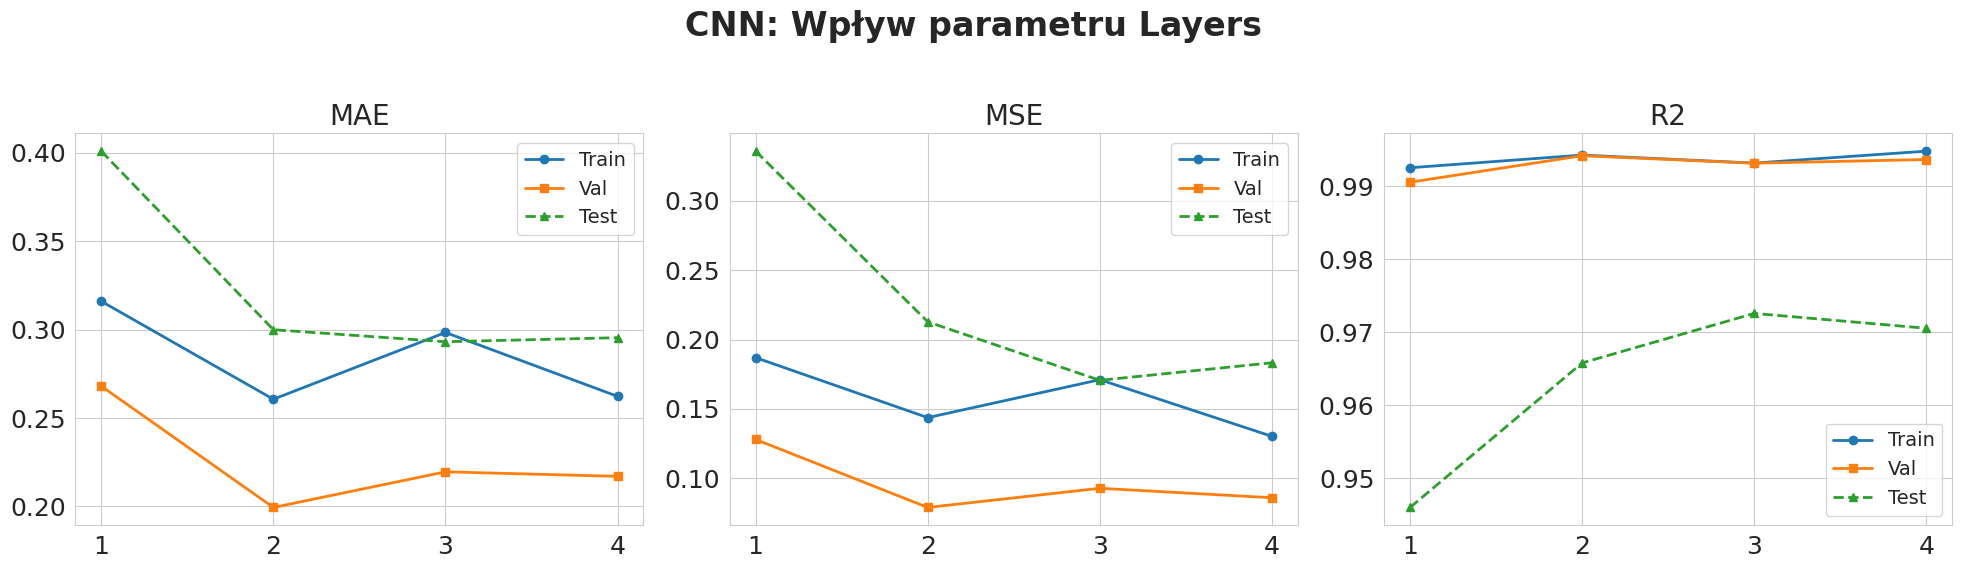

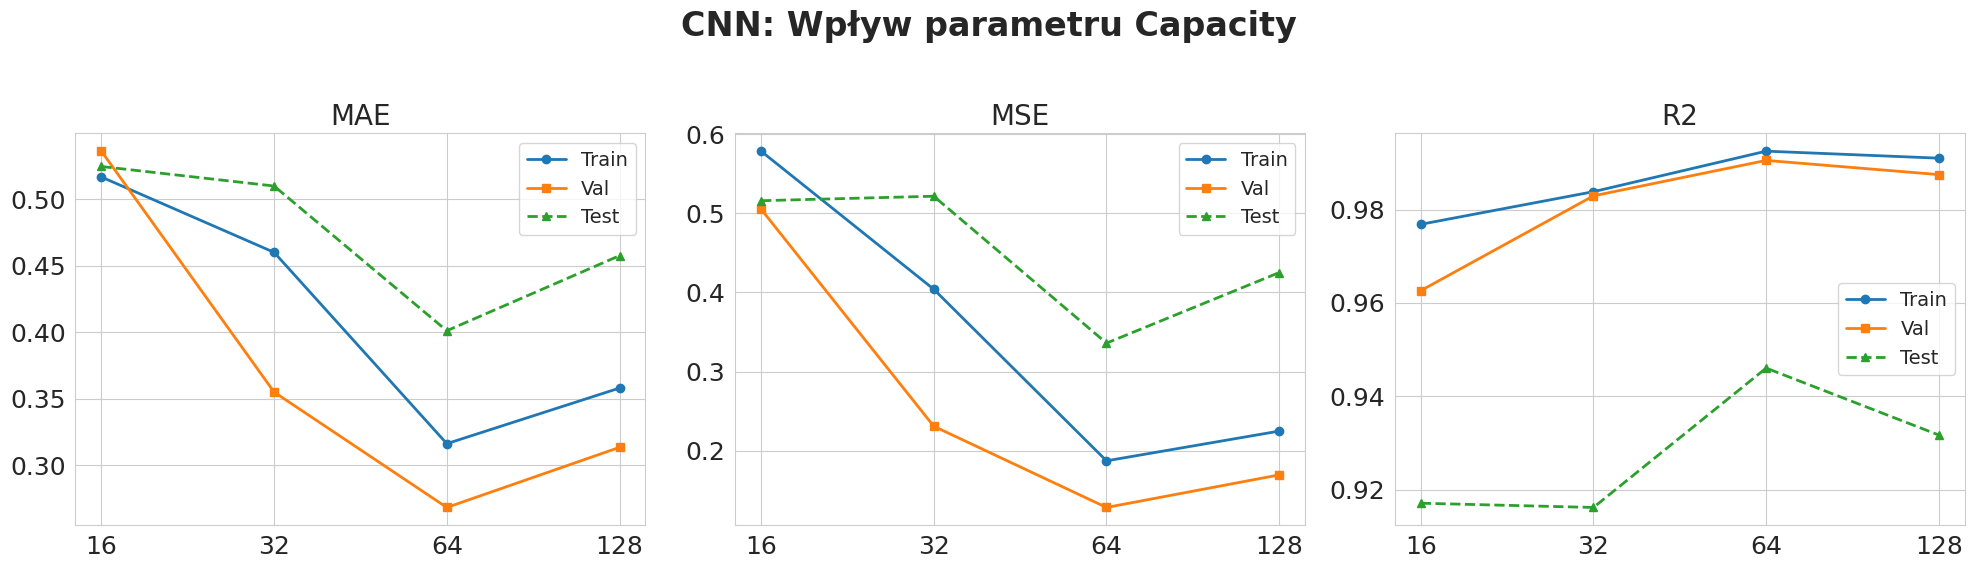

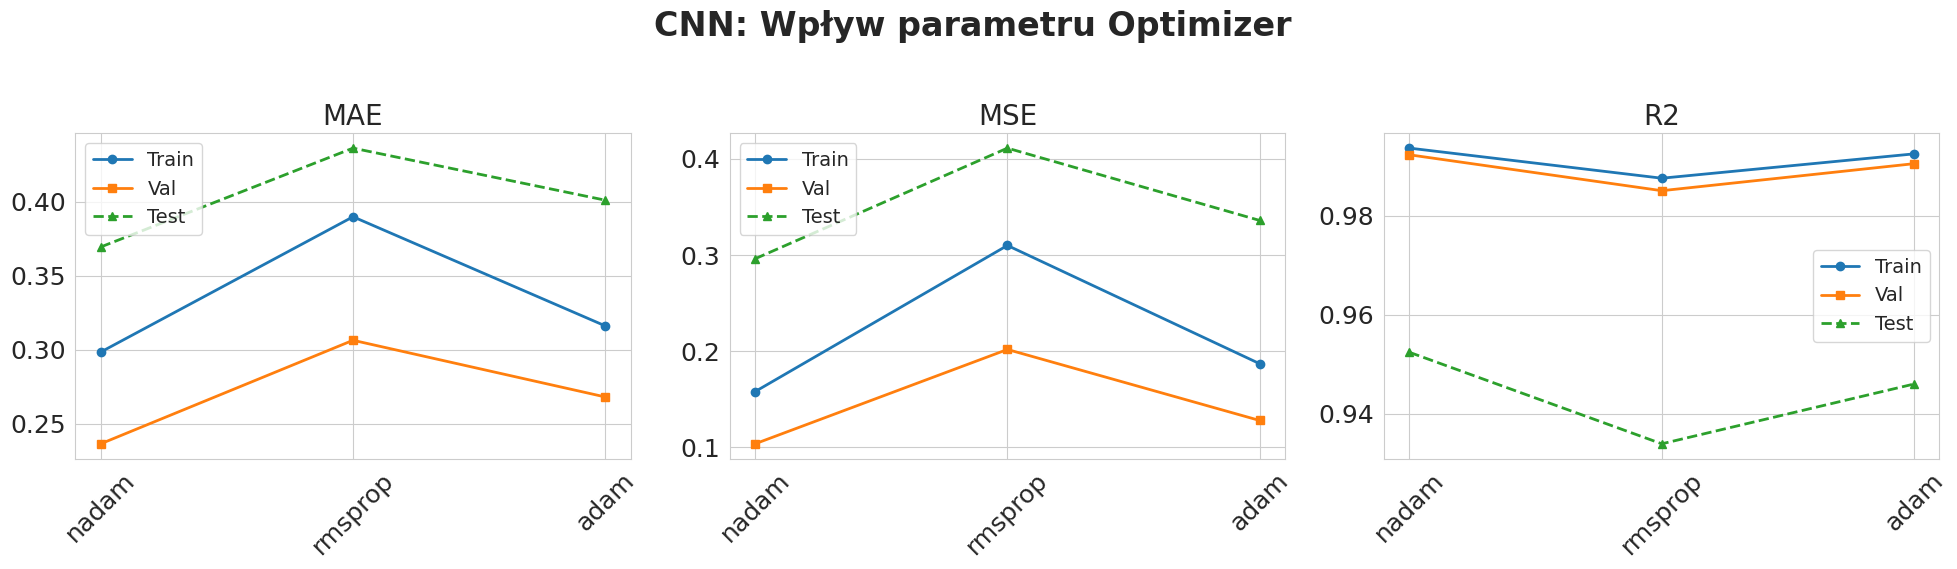

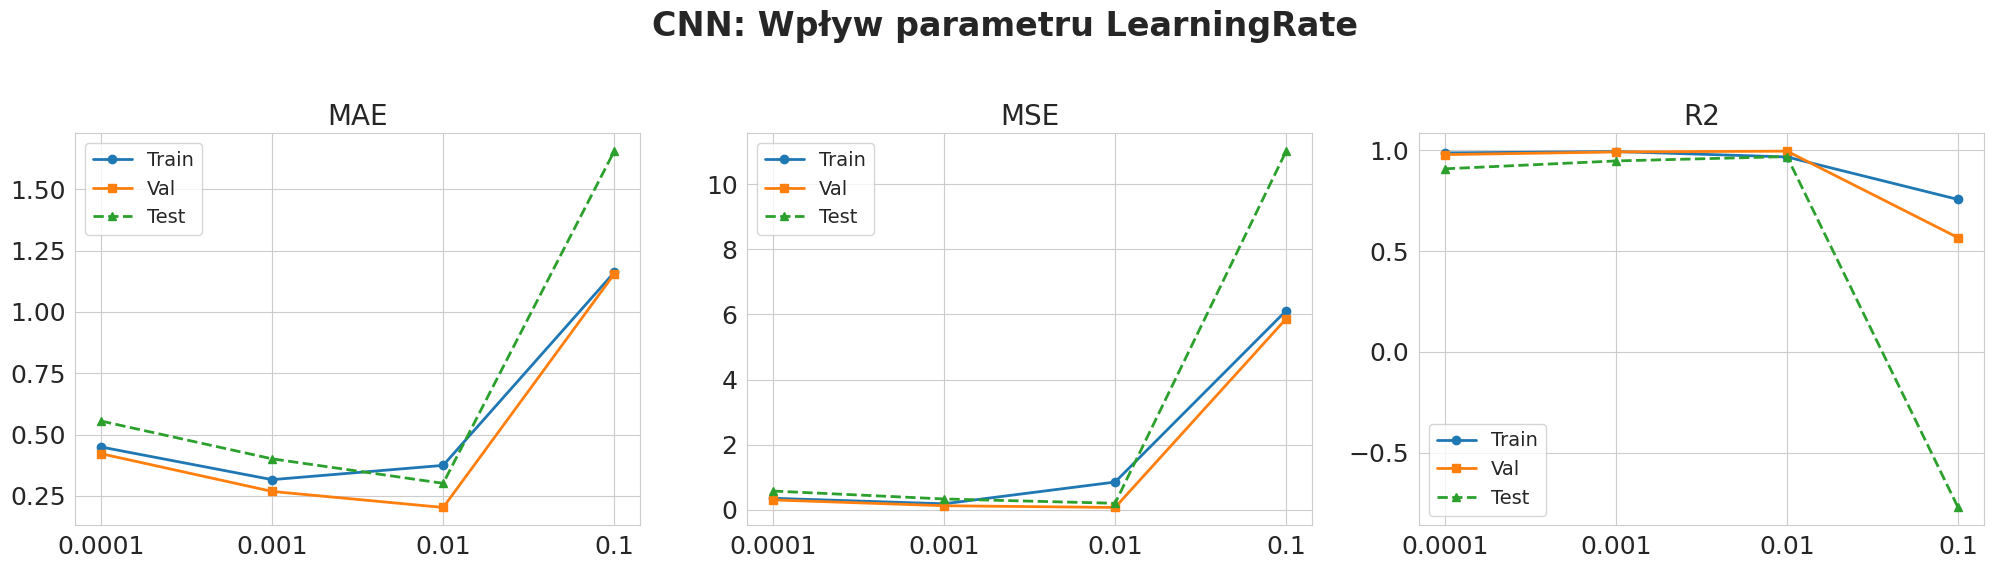

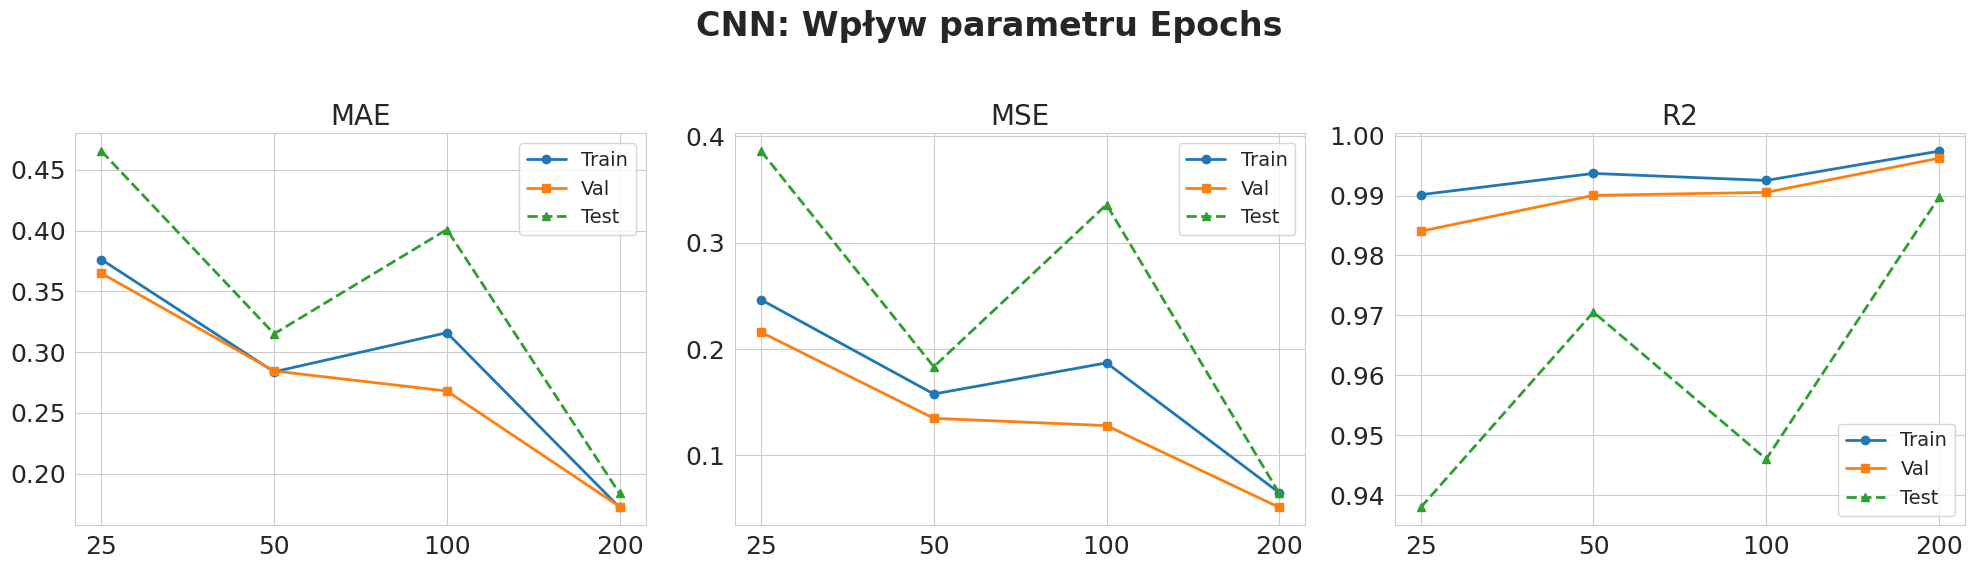

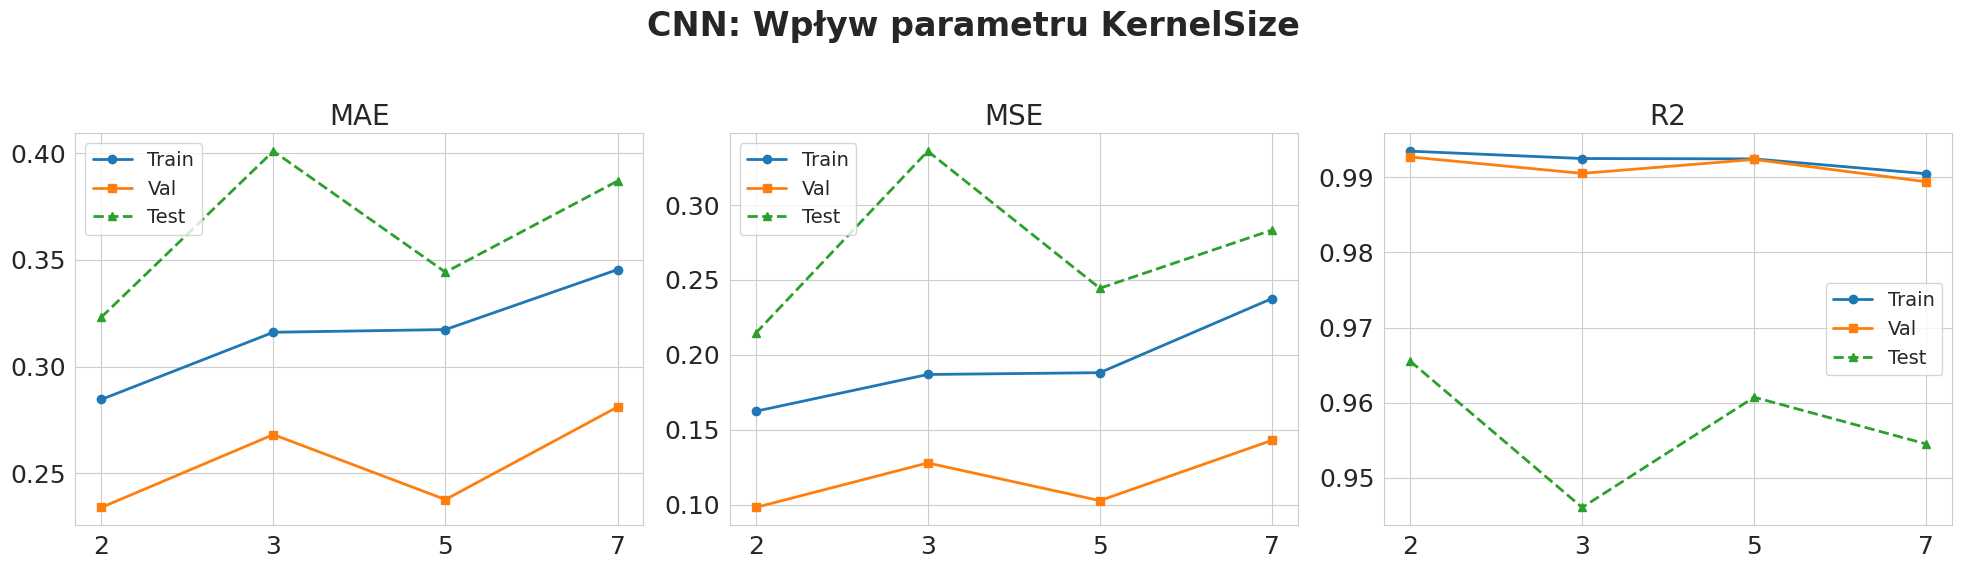

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# KONFIGURACJA
# ==========================================
FILENAME = 'wyniki_cnn_jena.csv'

if os.path.exists(FILENAME):
    df_res = pd.read_csv(FILENAME)
    print(f"Wczytano plik: {FILENAME}")
else:
    print(f"BŁĄD: Nie znaleziono pliku {FILENAME}")
    df_res = pd.DataFrame()

# ==========================================
# GENEROWANIE WYKRESÓW (CNN)
# ==========================================
if not df_res.empty:
    # 1. Styl i czcionki (według schematu)
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.size': 14,          # Bazowy rozmiar
        'axes.titlesize': 20,     # Tytuły poszczególnych wykresów
        'xtick.labelsize': 18,    # Liczby na osi X
        'ytick.labelsize': 18,    # Liczby na osi Y
        'legend.fontsize': 14,    # Legenda
        'figure.titlesize': 24    # Tytuł główny
    })

    param_map = {
        'Layers': 'num_layers',
        'Capacity': 'filters',
        'LearningRate': 'learning_rate',
        'Optimizer': 'optimizer',
        'Epochs': 'epochs',
        'KernelSize': 'kernel_size'
    }

    baseline_row = df_res[df_res['group'] == 'BASELINE']
    test_groups = [g for g in df_res['group'].unique() if g != 'BASELINE']

    print(f"Generuję wykresy dla grup: {test_groups}")

    for group in test_groups:
        if group not in param_map:
            continue

        x_col = param_map[group]
        subset = df_res[df_res['group'] == group].copy()

        # Dodanie baseline
        if not baseline_row.empty:
            subset = pd.concat([subset, baseline_row], ignore_index=True)

        # ---------------------------------------------------------
        # SORTOWANIE
        # ---------------------------------------------------------
        try:
            # Próba sortowania numerycznego
            subset['sort_val'] = pd.to_numeric(subset[x_col], errors='coerce')
            subset = subset.sort_values('sort_val')
        except:
            # Fallback (np. dla stringów)
            subset = subset.sort_values(x_col)

        # ---------------------------------------------------------
        # KLUCZ DO RÓWNYCH ODSTĘPÓW
        # ---------------------------------------------------------
        x_positions = np.arange(len(subset))
        x_labels = subset[x_col].astype(str).values

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'CNN: Wpływ parametru {group}', fontsize=24, fontweight='bold')

        # ---------------------------------------------------------
        # KONFIGURACJA METRYK (ZMIANA KOLEJNOŚCI: MAE, MSE, R2)
        # ---------------------------------------------------------
        metrics_config = [
            ('MAE', 'Train_MAE_Mean', 'Val_MAE_Mean', 'Test_MAE_Mean'),
            ('MSE', 'Train_MSE_Mean', 'Val_MSE_Mean', 'Test_MSE_Mean'),
            ('R2',  'Train_R2_Mean',  'Val_R2_Mean',  'Test_R2_Mean')
        ]

        for i, (name, tr_col, val_col, test_col) in enumerate(metrics_config):
            ax = axes[i]

            # Rysowanie względem pozycji (0, 1, 2...)
            ax.plot(x_positions, subset[tr_col], marker='o', label='Train', linewidth=2)
            ax.plot(x_positions, subset[val_col], marker='s', label='Val', linewidth=2)
            ax.plot(x_positions, subset[test_col], marker='^', label='Test', linewidth=2, linestyle='--')

            ax.set_title(name)

            # Ustawienie etykiet
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels)

            # Rotacja dla Optimizera
            if group == 'Optimizer':
                ax.tick_params(axis='x', rotation=45)

            ax.legend()
            ax.grid(True)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

In [9]:
import random
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 6. RANDOM SEARCH (CNN)
# ==========================================

N_RANDOM_SAMPLES = 30  # Liczba losowych kombinacji do przetestowania
N_REPEATS = 2          # Liczba powtórzeń dla każdej kombinacji

print(f"\n{'='*40}")
print(f"Rozpoczynam RANDOM SEARCH dla CNN ({N_RANDOM_SAMPLES} prób)\n")

random_experiments_queue = []

# Zaktualizowana przestrzeń poszukiwań dla modelu CNN
search_space = {
    'num_layers': [1, 2,3],          # Liczba warstw Conv1D
    'filters': [ 32,64],     # Liczba filtrów w warstwach
    'kernel_size': [2, 3,5],         # Rozmiar okna konwolucji
    'optimizer': ['adam', 'nadam'],
    'learning_rate': [0.01, 0.001],
    'epochs': [25, 50, 100,200],
}

# Parametry stałe (zgodne z logiką kodu LSTM)
fixed_time_steps = 24
fixed_momentum = 0.0

# --------------------------------------------------------------

for _ in range(N_RANDOM_SAMPLES):
    # Tworzymy nową konfigurację od podstaw, uwzględniając stałe parametry
    # Kopiujemy BASELINE_CONFIG, aby zapewnić wszystkie domyślne parametry (np. dense_neurons)
    random_cfg = BASELINE_CONFIG.copy()
    random_cfg['group'] = 'RANDOM_SEARCH'
    random_cfg['time_steps'] = fixed_time_steps # Upewniamy się, że time_steps jest zgodne
    random_cfg['momentum'] = fixed_momentum # Upewniamy się, że momentum jest zgodne

    # Losujemy wartości dla każdego parametru z przestrzeni poszukiwań
    for param, values_list in search_space.items():
        random_cfg[param] = random.choice(values_list)


    if 'filters' in random_cfg:
        random_cfg['dense_neurons'] = random_cfg['filters']

    random_experiments_queue.append(random_cfg)

print(f"Wygenerowano {len(random_experiments_queue)} losowych konfiguracji do przetestowania.")

random_search_results = []
current_run_rs = 0
total_runs_rs = len(random_experiments_queue) * N_REPEATS

for cfg in random_experiments_queue:
    current_run_rs_exp = 0

    # Zaktualizowany string printujący konfigurację dla CNN
    print(f"\n>>> RANDOM SEARCH: Konfiguracja {cfg.get('group', 'UNKNOWN')} | " \
          f"Layers: {cfg.get('num_layers', 'N/A')}, Filters: {cfg.get('filters', 'N/A')}, " \
          f"Kernel: {cfg.get('kernel_size', 'N/A')}, Dense: {cfg.get('dense_neurons', 'N/A')}, " \
          f"LR: {cfg.get('learning_rate', 'N/A')}")

    metrics = {k: [] for k in ['Train_R2', 'Val_R2', 'Test_R2',
                               'Train_MAE', 'Val_MAE', 'Test_MAE',
                               'Train_MSE', 'Val_MSE', 'Test_MSE']}

    for i in range(N_REPEATS):
        current_run_rs += 1
        current_run_rs_exp += 1

        # Budowanie modelu CNN
        model = build_cnn_model((X_train.shape[1], X_train.shape[2]), cfg)

        # EarlyStopping tylko jeśli nie testujemy 'Epochs'
        cbs = []
        if cfg.get('group') != 'Epochs':
             cbs.append(EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True))

        model.fit(X_train, y_train_scaled, validation_data=(X_val, y_val_scaled),
                  epochs=cfg['epochs'], batch_size=128, verbose=0, callbacks=cbs)

        p_train = scaler_y.inverse_transform(model.predict(X_train, verbose=0))
        p_val   = scaler_y.inverse_transform(model.predict(X_val, verbose=0))
        p_test  = scaler_y.inverse_transform(model.predict(X_test, verbose=0))

        # Zabezpieczenie przed NaN (gdyby sieć \"wybuchła\")
        if np.isnan(p_test).any():
            print("! UWAGA: NaN w wynikach. Przypisuję błędy domyślne.")
            scores = [0]*3 + [999]*6
        else:
            # Obliczenie wszystkich metryk w jednym bloku
            scores = [
                r2_score(y_true_train, p_train), r2_score(y_true_val, p_val), r2_score(y_true_test, p_test),
                mean_absolute_error(y_true_train, p_train), mean_absolute_error(y_true_val, p_val), mean_absolute_error(y_true_test, p_test),
                mean_squared_error(y_true_train, p_train), mean_squared_error(y_true_val, p_val), mean_squared_error(y_true_test, p_test)
            ]

        # Zapis wyników do list
        for key, val in zip(metrics.keys(), scores):
            metrics[key].append(val)

        print(f"    Run {current_run_rs}/{total_runs_rs}: Test R2={metrics['Test_R2'][-1]:.4f} | MSE={metrics['Test_MSE'][-1]:.2f}")

    # Obliczanie średnich i zapis do listy głównej
    res = cfg.copy()
    for key, val_list in metrics.items():
        res[f'{key}_Mean'] = np.mean(val_list)

    random_search_results.append(res)

# ==========================================
# ZAPIS WYNIKÓW RANDOM SEARCH I WYBÓR NAJLEPSZEGO MODELU
# ==========================================
df_random_res = pd.DataFrame(random_search_results)
filename_random_out = 'cnn_random_search_results.csv' # Zmieniona nazwa pliku dla rozróżnienia
df_random_res.to_csv(filename_random_out, index=False)

print(f"\n{'='*40}")
print(f"             KONIEC RANDOM SEARCH (CNN)        ")
print(f"{'='*40}")
print(f"Pełne wyniki random search zapisano w: {filename_random_out}")

# Znajdowanie najlepszego modelu (na podstawie Test_R2_Mean)
best_model_rs = df_random_res.loc[df_random_res['Test_R2_Mean'].idxmax()]

print("\n--- NAJLEPSZY MODEL Z RANDOM SEARCH (CNN - wg. Test_R2_Mean) ---")
print(f"Konfiguracja:")
# Wyświetlamy parametry istotne dla CNN
cnn_params = ['num_layers', 'filters', 'kernel_size', 'dense_neurons', 'optimizer', 'learning_rate', 'epochs', 'time_steps']
for key in cnn_params:
    if key in best_model_rs:
        print(f"  {key}: {best_model_rs[key]}")

print(f"Wyniki (średnie z {N_REPEATS} powtórzeń):")
print(f"  Train R2: {best_model_rs['Train_R2_Mean']:.4f}")
print(f"  Val   R2: {best_model_rs['Val_R2_Mean']:.4f}")
print(f"  Test  R2: {best_model_rs['Test_R2_Mean']:.4f}")
print(f"  Train MAE: {best_model_rs['Train_MAE_Mean']:.4f}")
print(f"  Val   MAE: {best_model_rs['Val_MAE_Mean']:.4f}")
print(f"  Test  MAE: {best_model_rs['Test_MAE_Mean']:.4f}")
print(f"  Train MSE: {best_model_rs['Train_MSE_Mean']:.4f}")
print(f"  Val   MSE: {best_model_rs['Val_MSE_Mean']:.4f}")
print(f"  Test  MSE: {best_model_rs['Test_MSE_Mean']:.4f}")



Rozpoczynam RANDOM SEARCH dla CNN (30 prób)

Wygenerowano 30 losowych konfiguracji do przetestowania.

>>> RANDOM SEARCH: Konfiguracja RANDOM_SEARCH | Layers: 1, Filters: 64, Kernel: 3, Dense: 64, LR: 0.001


KeyboardInterrupt: 